# A global signal is not local heat exposure

**Climate & Health · Lesson 01 · 20–35 minutes**

[Run this lesson in Python Lab](https://jltobias.github.io/JupyterLite-Climate-and-Health/lite/lab/index.html?path=notebooks/01_global_temperature.ipynb)

Read a real global annual temperature anomaly series, check the baseline and compare periods. NASA GISTEMP v4 blends global land and ocean information; the anomaly is relative to 1951–1980. It is neither absolute temperature nor a European regional mean.

**Learning goal:** Run the analysis, explain its units and assumptions, then adapt the exercise.

Data labels: **observed NASA** appears in lesson 01. Fictional facility scenarios, local temperatures, costs, flows and modeled impacts are **synthetic teaching data**. The separate **archived Healthsites / OpenStreetMap points** are actual public map records with unverified current services; no synthetic impacts or funding claims apply to them.

In [1]:
from pathlib import Path
import sys, json, statistics
root = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "healthlab.py").exists()), None)
if root is None:
    raise RuntimeError("Open this notebook inside the bundled content folder; healthlab.py and data/ are required.")
if str(root) not in sys.path: sys.path.insert(0, str(root))
import healthlab as h
from IPython.display import display, SVG
cases = h.cases()
print("Loaded", len(cases), "fictional facility scenarios; city coordinates are context only.")

Loaded 7 fictional facility scenarios; city coordinates are context only.


## Analysis 1

Run this cell, then inspect the units and result before continuing.

Observed annual coverage: 1880 to 2025


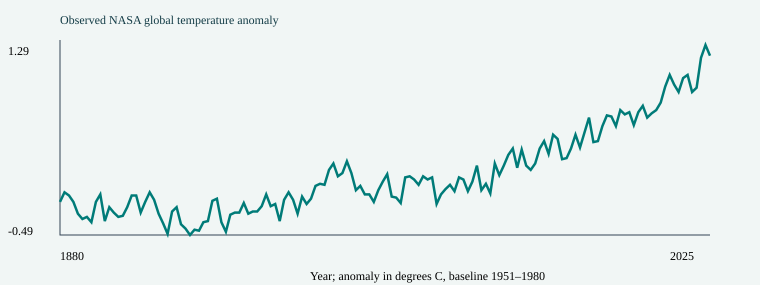

In [2]:
rows = h.read_csv("global-temperature.csv")
years = [int(r["year"]) for r in rows]
anomalies = [float(r["anomaly_c"]) for r in rows]
assert len(years) == len(set(years)) and all(r["data_type"] == "observed" for r in rows)
print("Observed annual coverage:", min(years), "to", max(years))
display(SVG(h.line_svg(years, anomalies, "Observed NASA global temperature anomaly", "Year; anomaly in degrees C, baseline 1951–1980")))

## Analysis 2

Run this cell, then inspect the units and result before continuing.

In [3]:
def period_mean(start, end):
    values = [a for y,a in zip(years, anomalies) if start <= y <= end]
    if len(values) != end-start+1: raise ValueError("Incomplete annual period")
    return statistics.mean(values)
early, recent = period_mean(1951,1980), period_mean(1991,2020)
print(f"1951–1980: {early:.3f} °C; 1991–2020: {recent:.3f} °C; difference: {recent-early:.3f} °C")

1951–1980: 0.000 °C; 1991–2020: 0.613 °C; difference: 0.612 °C


## Interpretation

A baseline changes the zero, not the underlying warming difference. The annual global mean cannot identify heatwaves in Mumbai, Beira or Lagos. The snapshot is fixed at its acquisition date, and incomplete annual rows were excluded.

## Your exercise

Compare 1981–2010 with 1991–2020. Explain why overlapping periods are not independent samples. Name the local humidity, nighttime heat and occupational-exposure data needed for a heat-health question.

## Worked reasoning check

Before trusting a changed result, identify the input you changed, predict the direction, and compare with the printed baseline. Explain any threshold or missing-data behavior; a valid calculation alone does not validate a real-world claim.

## Source and limitation

GISTEMP Team (2026), https://data.giss.nasa.gov/gistemp/ ; Lenssen et al. (2024), https://doi.org/10.1029/2023JD040179 . See data/provenance.json for retrieval date and raw SHA-256. Observational uncertainty is not represented by this one-series plot.

Original educational text: CC BY 4.0, James L. Tobias and contributors. Original synthetic fixtures: CC0. Original calculation code: MIT.